# Bounded process (proportions and rates)

Many series live inside fixed bounds — proportions, utilization rates, market shares that must stay in [0, 1]. A bounded process keeps values inside the interval while still allowing autocorrelation and mean reversion, unlike an unbounded random walk that would eventually escape.

::: {.callout-note}
## The model

Pick `model="beta_ar"` (a Beta-distributed autoregression that mean-reverts inside the interval) or `model="logit_normal"` (a random walk in logit space mapped back to (0, 1)). Both guarantee valid bounded output with tunable persistence.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import BoundedProcessGenerator

## 1. Beta-AR model (proportions in [0, 1])

The Beta-AR model uses a conditional Beta distribution where the mean depends on the previous value: `mu_t = omega + phi * x_{t-1}`.

In [ ]:
beta_gen = BoundedProcessGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    model="beta_ar",
    phi=0.8,
    omega=0.1,
    kappa=20.0,
    seed=42,
)
beta_df = beta_gen.generate(n_series=1)

print(f"Generated {len(beta_df)} observations in [0, 1]")
print(f"Min={beta_df['y'].min():.4f}, Max={beta_df['y'].max():.4f}")
beta_df.head(10)

Generated 200 observations in [0, 1]
Min=0.1017, Max=0.8915


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,0.314116
"""0""",2000-01-02 00:00:00,0.268915
"""0""",2000-01-03 00:00:00,0.226411
"""0""",2000-01-04 00:00:00,0.396161
"""0""",2000-01-05 00:00:00,0.349861
"""0""",2000-01-06 00:00:00,0.397705
"""0""",2000-01-07 00:00:00,0.464456
"""0""",2000-01-08 00:00:00,0.416668
"""0""",2000-01-09 00:00:00,0.336088


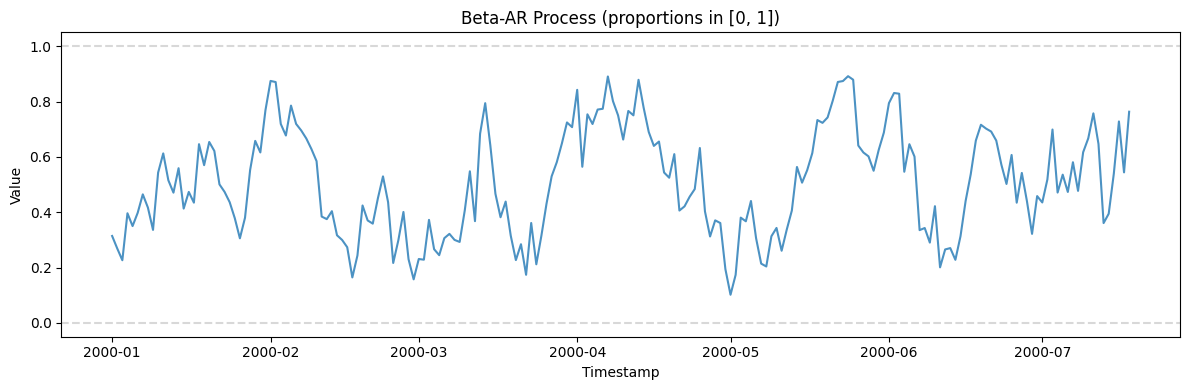

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(beta_df["ds"].to_list(), beta_df["y"].to_list(), alpha=0.8)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Beta-AR Process (proportions in [0, 1])")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 2. Logit-normal model

The logit-normal model works in logit space: `z_t = phi * z_{t-1} + sigma * eps`, then `x_t = sigmoid(z_t)`. This naturally stays in (0, 1).

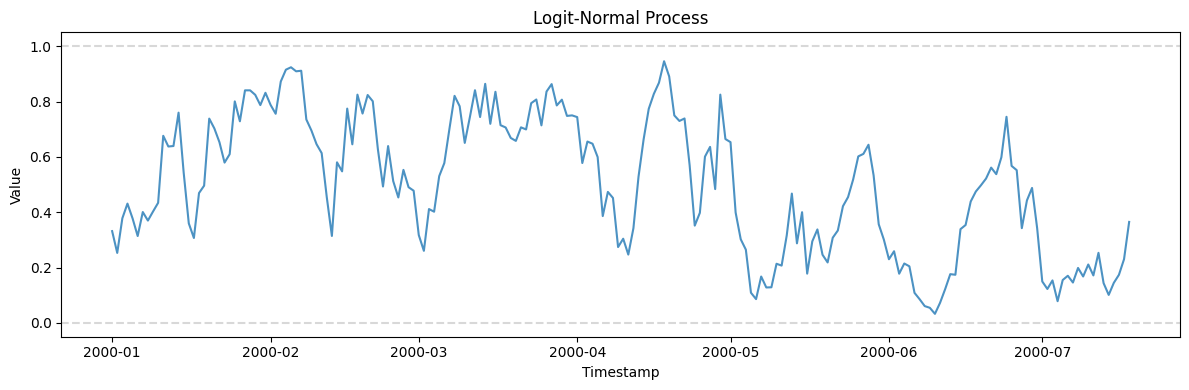

In [ ]:
logit_gen = BoundedProcessGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    model="logit_normal",
    phi=0.9,
    sigma=0.5,
    seed=42,
)
logit_df = logit_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(logit_df["ds"].to_list(), logit_df["y"].to_list(), alpha=0.8)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Logit-Normal Process")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 3. Custom bounds

Scale the output to any `[lower, upper]` interval, e.g., temperature in [15, 35].

Min=21.01, Max=34.23


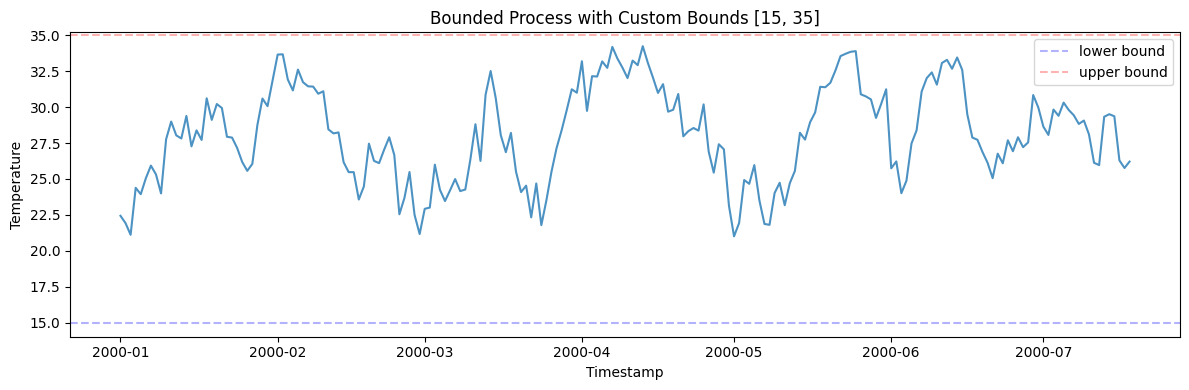

In [ ]:
temp_gen = BoundedProcessGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    model="beta_ar",
    phi=0.85,
    omega=0.1,
    kappa=30.0,
    lower=15.0,
    upper=35.0,
    seed=42,
)
temp_df = temp_gen.generate(n_series=1)

print(f"Min={temp_df['y'].min():.2f}, Max={temp_df['y'].max():.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(temp_df["ds"].to_list(), temp_df["y"].to_list(), alpha=0.8)
ax.axhline(y=15, color="blue", linestyle="--", alpha=0.3, label="lower bound")
ax.axhline(y=35, color="red", linestyle="--", alpha=0.3, label="upper bound")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature")
ax.set_title("Bounded Process with Custom Bounds [15, 35]")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Multiple series

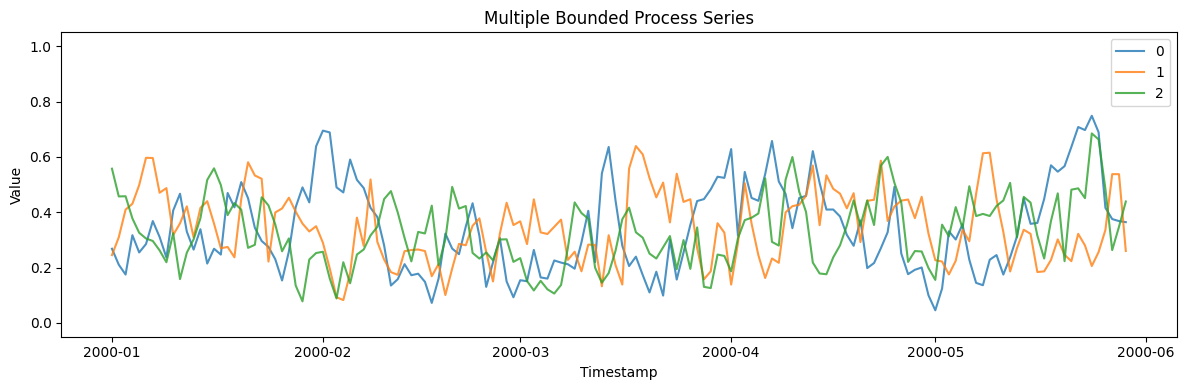

In [ ]:
multi_gen = BoundedProcessGenerator(engine="polars", 
    min_length=150, max_length=150, freq="D",
    model="beta_ar", phi=0.7, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Bounded Process Series")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Ornstein-Uhlenbeck](ornstein_uhlenbeck) — unbounded mean reversion.
- [INAR](../statistical/inar) — bounded-below integer counts.

Model choices and parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::